# ❤️ Heart Disease AI System — PRCP-1016
**Domain:** Healthcare | **Type:** Binary Classification  
**Target:** `heart_disease_present` → 0 = No Disease, 1 = Disease Present

---
| Section | Description |
|---------|-------------|
| 1 | Library Imports & Project Setup |
| 2 | Data Loading & Overview |
| 3 | Exploratory Data Analysis — Task 1 |
| 4 | Data Preprocessing |
| 5 | Model Building — Task 2 |
| 6 | Model Comparison Report |
| 7 | Save Best Model |
| 8 | Generate PDF Report |
| 9 | Challenges Report |
| 10 | Hospital Recommendations — Task 3 |

---
## Section 1 — Library Imports & Project Setup

In [1]:
import os, sys, warnings, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score,
                             roc_curve, accuracy_score,
                             precision_score, recall_score, f1_score)
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.tree            import DecisionTreeClassifier
from xgboost                 import XGBClassifier
from imblearn.over_sampling  import SMOTE

# ── Path setup ──────────────────────────────────────────────────────────────
BASE   = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA   = os.path.join(BASE, 'Dataset')
MODELS = os.path.join(BASE, 'Saved_Model')
CHARTS = os.path.join(BASE, 'Images', 'charts')
REPORT = os.path.join(BASE, 'Reports')
for p in [MODELS, CHARTS, REPORT]:
    os.makedirs(p, exist_ok=True)

# ── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams['figure.dpi']   = 110
plt.rcParams['savefig.dpi']  = 150
plt.rcParams['savefig.bbox'] = 'tight'
sns.set_style('whitegrid')
PALETTE = ['#51cf66', '#ff6b6b']

def save_chart(name):
    path = os.path.join(CHARTS, name)
    plt.savefig(path)
    print(f'  Chart saved → {path}')

print('✅  All libraries imported')
print(f'   Base path : {BASE}')
print(f'   Data path : {DATA}')
print(f'   Charts    : {CHARTS}')

✅  All libraries imported
   Base path : C:\Users\Harsha\Heart_Disease_AI_System
   Data path : C:\Users\Harsha\Heart_Disease_AI_System\Dataset
   Charts    : C:\Users\Harsha\Heart_Disease_AI_System\Images\charts


---
## Section 2 — Data Loading & Overview

In [2]:
values = pd.read_csv(os.path.join(DATA, 'values.csv'))
labels = pd.read_csv(os.path.join(DATA, 'labels.csv'))
df     = values.merge(labels, on='patient_id')

print(f'values.csv  : {values.shape}')
print(f'labels.csv  : {labels.shape}')
print(f'Merged      : {df.shape}')
df.head()

values.csv  : (180, 14)
labels.csv  : (180, 2)
Merged      : (180, 15)


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [3]:
print('Data Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())
print('\nDuplicate Rows:', df.duplicated().sum())

Data Types:
patient_id                               object
slope_of_peak_exercise_st_segment         int64
thal                                     object
resting_blood_pressure                    int64
chest_pain_type                           int64
num_major_vessels                         int64
fasting_blood_sugar_gt_120_mg_per_dl      int64
resting_ekg_results                       int64
serum_cholesterol_mg_per_dl               int64
oldpeak_eq_st_depression                float64
sex                                       int64
age                                       int64
max_heart_rate_achieved                   int64
exercise_induced_angina                   int64
heart_disease_present                     int64
dtype: object

Missing Values:
patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels          

In [4]:
print('Statistical Summary:')
df.describe().round(2)

Statistical Summary:


,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.00,180.00,180.00,180.00,180.00,180.00,180.00,180.00,180.00,180.00,180.00,180.00,180.00
mean,1.55,131.31,3.16,0.69,0.16,1.05,249.21,1.01,0.69,54.81,149.48,0.32,0.44
std,0.62,17.01,0.94,0.97,0.37,1.00,52.72,1.12,0.46,9.33,22.06,0.47,0.50
min,1.00,94.00,1.00,0.00,0.00,0.00,126.00,0.00,0.00,29.00,96.00,0.00,0.00
25%,1.00,120.00,3.00,0.00,0.00,0.00,213.75,0.00,0.00,48.00,132.00,0.00,0.00
50%,1.00,130.00,3.00,0.00,0.00,2.00,245.50,0.80,1.00,55.00,152.00,0.00,0.00
75%,2.00,140.00,4.00,1.00,0.00,2.00,281.25,1.60,1.00,62.00,166.25,1.00,1.00
max,3.00,180.00,4.00,3.00,1.00,2.00,564.00,6.20,1.00,77.00,202.00,1.00,1.00


---
## Section 3 — Exploratory Data Analysis — Task 1

### 3.1 — Target Variable Distribution

  Chart saved → C:\Users\Harsha\Heart_Disease_AI_System\Images\charts\01_target_distribution.png


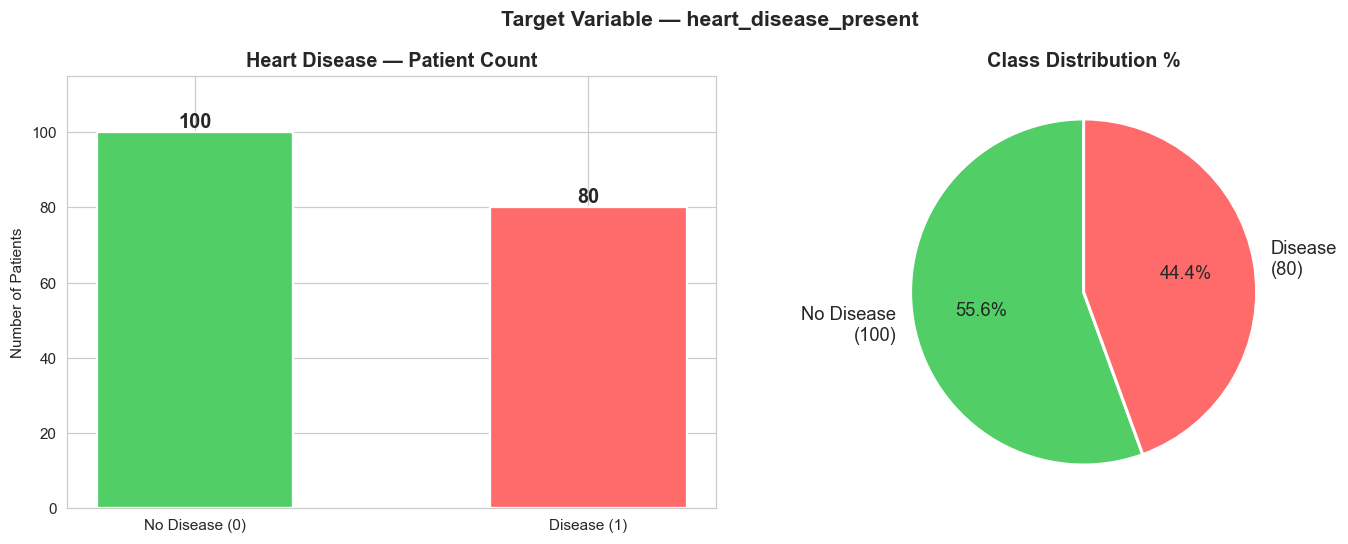

No Disease (0): 100 (55.6%)
Disease    (1): 80 (44.4%)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
counts = df['heart_disease_present'].value_counts()

bars = axes[0].bar(['No Disease (0)', 'Disease (1)'], counts.values,
                   color=PALETTE, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.2,
                 str(val), ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Heart Disease — Patient Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
axes[0].set_ylim(0, max(counts.values)+15)

axes[1].pie(counts.values,
            labels=[f'No Disease\n({counts[0]})', f'Disease\n({counts[1]})'],
            colors=PALETTE, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12}, wedgeprops={'edgecolor': 'white','linewidth':2})
axes[1].set_title('Class Distribution %', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable — heart_disease_present', fontsize=14, fontweight='bold')
plt.tight_layout()
save_chart('01_target_distribution.png')
plt.show()
print(f'No Disease (0): {counts[0]} ({counts[0]/len(df)*100:.1f}%)')
print(f'Disease    (1): {counts[1]} ({counts[1]/len(df)*100:.1f}%)')

**Observation:** 100 patients (55.6%) have no heart disease, 80 (44.4%) have heart disease. Mild class imbalance addressed with SMOTE.

### 3.2 — Age Analysis

  Chart saved → C:\Users\Harsha\Heart_Disease_AI_System\Images\charts\02_age_analysis.png


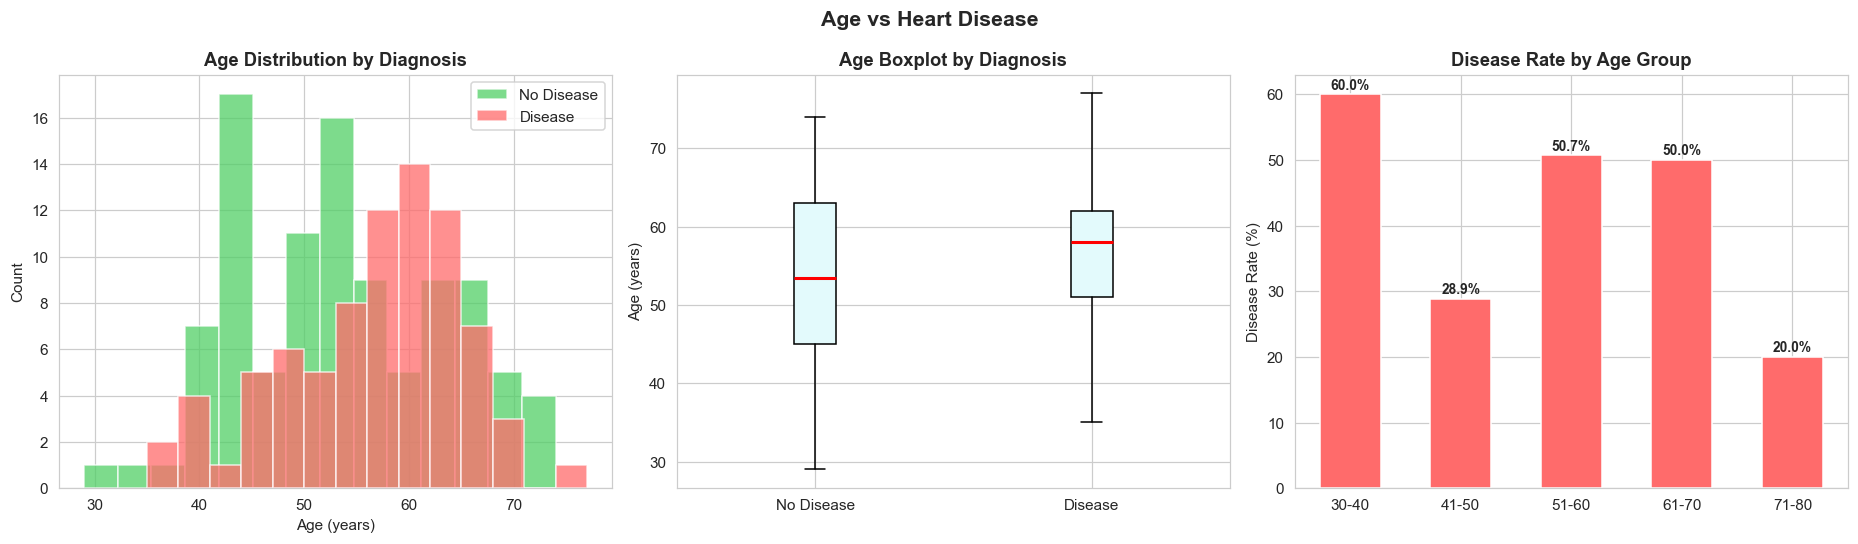

Mean age — No Disease: 53.7
Mean age — Disease   : 56.2


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for val, color, lbl in zip([0,1], PALETTE, ['No Disease','Disease']):
    axes[0].hist(df[df['heart_disease_present']==val]['age'],
                 bins=14, alpha=0.75, color=color, label=lbl, edgecolor='white')
axes[0].set_title('Age Distribution by Diagnosis', fontweight='bold')
axes[0].set_xlabel('Age (years)'); axes[0].set_ylabel('Count'); axes[0].legend()

bp = axes[1].boxplot(
    [df[df['heart_disease_present']==0]['age'], df[df['heart_disease_present']==1]['age']],
    labels=['No Disease','Disease'], patch_artist=True,
    boxprops=dict(facecolor='#e3fafc'), medianprops=dict(color='red',linewidth=2))
axes[1].set_title('Age Boxplot by Diagnosis', fontweight='bold')
axes[1].set_ylabel('Age (years)')

df['age_group'] = pd.cut(df['age'], bins=[29,40,50,60,70,80],
                          labels=['30-40','41-50','51-60','61-70','71-80'])
ag = df.groupby('age_group', observed=True)['heart_disease_present'].mean()*100
bars2 = axes[2].bar(ag.index, ag.values, color='#ff6b6b', edgecolor='white', width=0.55)
for b in bars2:
    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+0.8,
                 f'{b.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[2].set_title('Disease Rate by Age Group', fontweight='bold')
axes[2].set_ylabel('Disease Rate (%)')

plt.suptitle('Age vs Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
save_chart('02_age_analysis.png')
plt.show()
print('Mean age — No Disease:', df[df['heart_disease_present']==0]['age'].mean().round(1))
print('Mean age — Disease   :', df[df['heart_disease_present']==1]['age'].mean().round(1))

### 3.3 — Clinical Features vs Heart Disease

  Chart saved → C:\Users\Harsha\Heart_Disease_AI_System\Images\charts\03_clinical_features.png


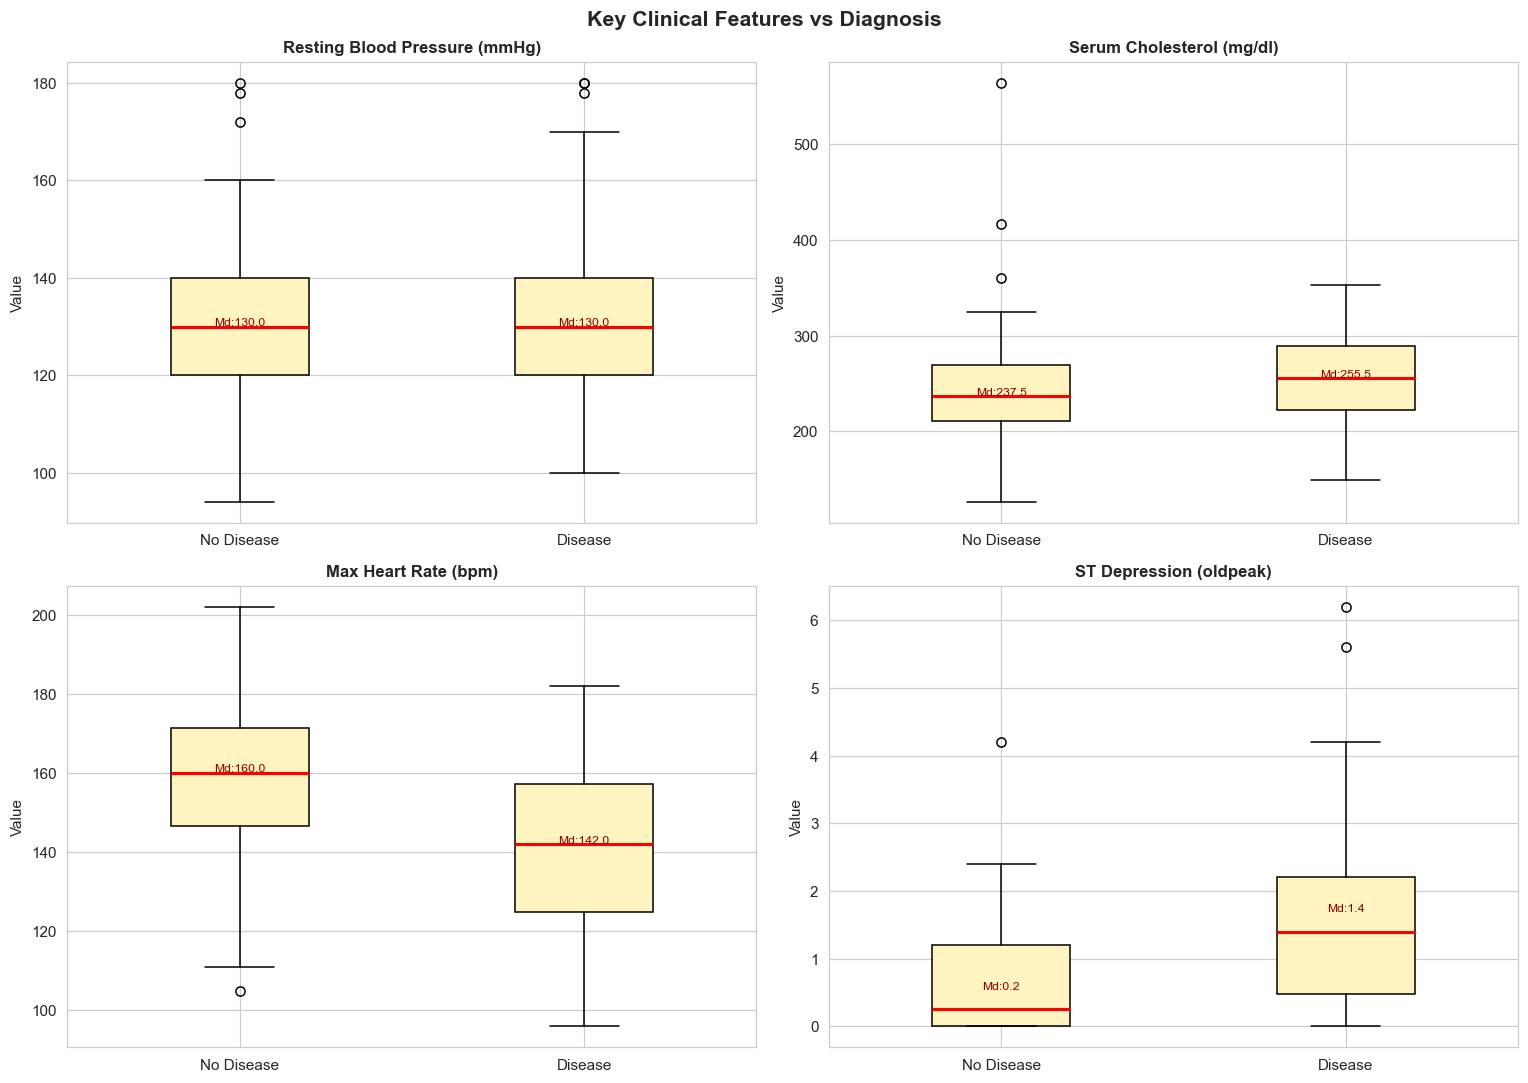

In [7]:
clinical = [
    ('resting_blood_pressure',     'Resting Blood Pressure (mmHg)'),
    ('serum_cholesterol_mg_per_dl','Serum Cholesterol (mg/dl)'),
    ('max_heart_rate_achieved',    'Max Heart Rate (bpm)'),
    ('oldpeak_eq_st_depression',   'ST Depression (oldpeak)')
]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (col, title) in zip(axes.flatten(), clinical):
    d0 = df[df['heart_disease_present']==0][col]
    d1 = df[df['heart_disease_present']==1][col]
    bp = ax.boxplot([d0, d1], labels=['No Disease','Disease'], patch_artist=True,
               boxprops=dict(facecolor='#fff3bf'),
               medianprops=dict(color='red', linewidth=2), widths=0.4)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('Value')
    for i, data in enumerate([d0, d1], 1):
        ax.text(i, data.median()+0.3, f'Md:{data.median():.1f}',
                ha='center', fontsize=8, color='darkred')
plt.suptitle('Key Clinical Features vs Diagnosis', fontsize=14, fontweight='bold')
plt.tight_layout()
save_chart('03_clinical_features.png')
plt.show()

### 3.4 — Categorical Features vs Heart Disease

  Chart saved → C:\Users\Harsha\Heart_Disease_AI_System\Images\charts\04_categorical_features.png


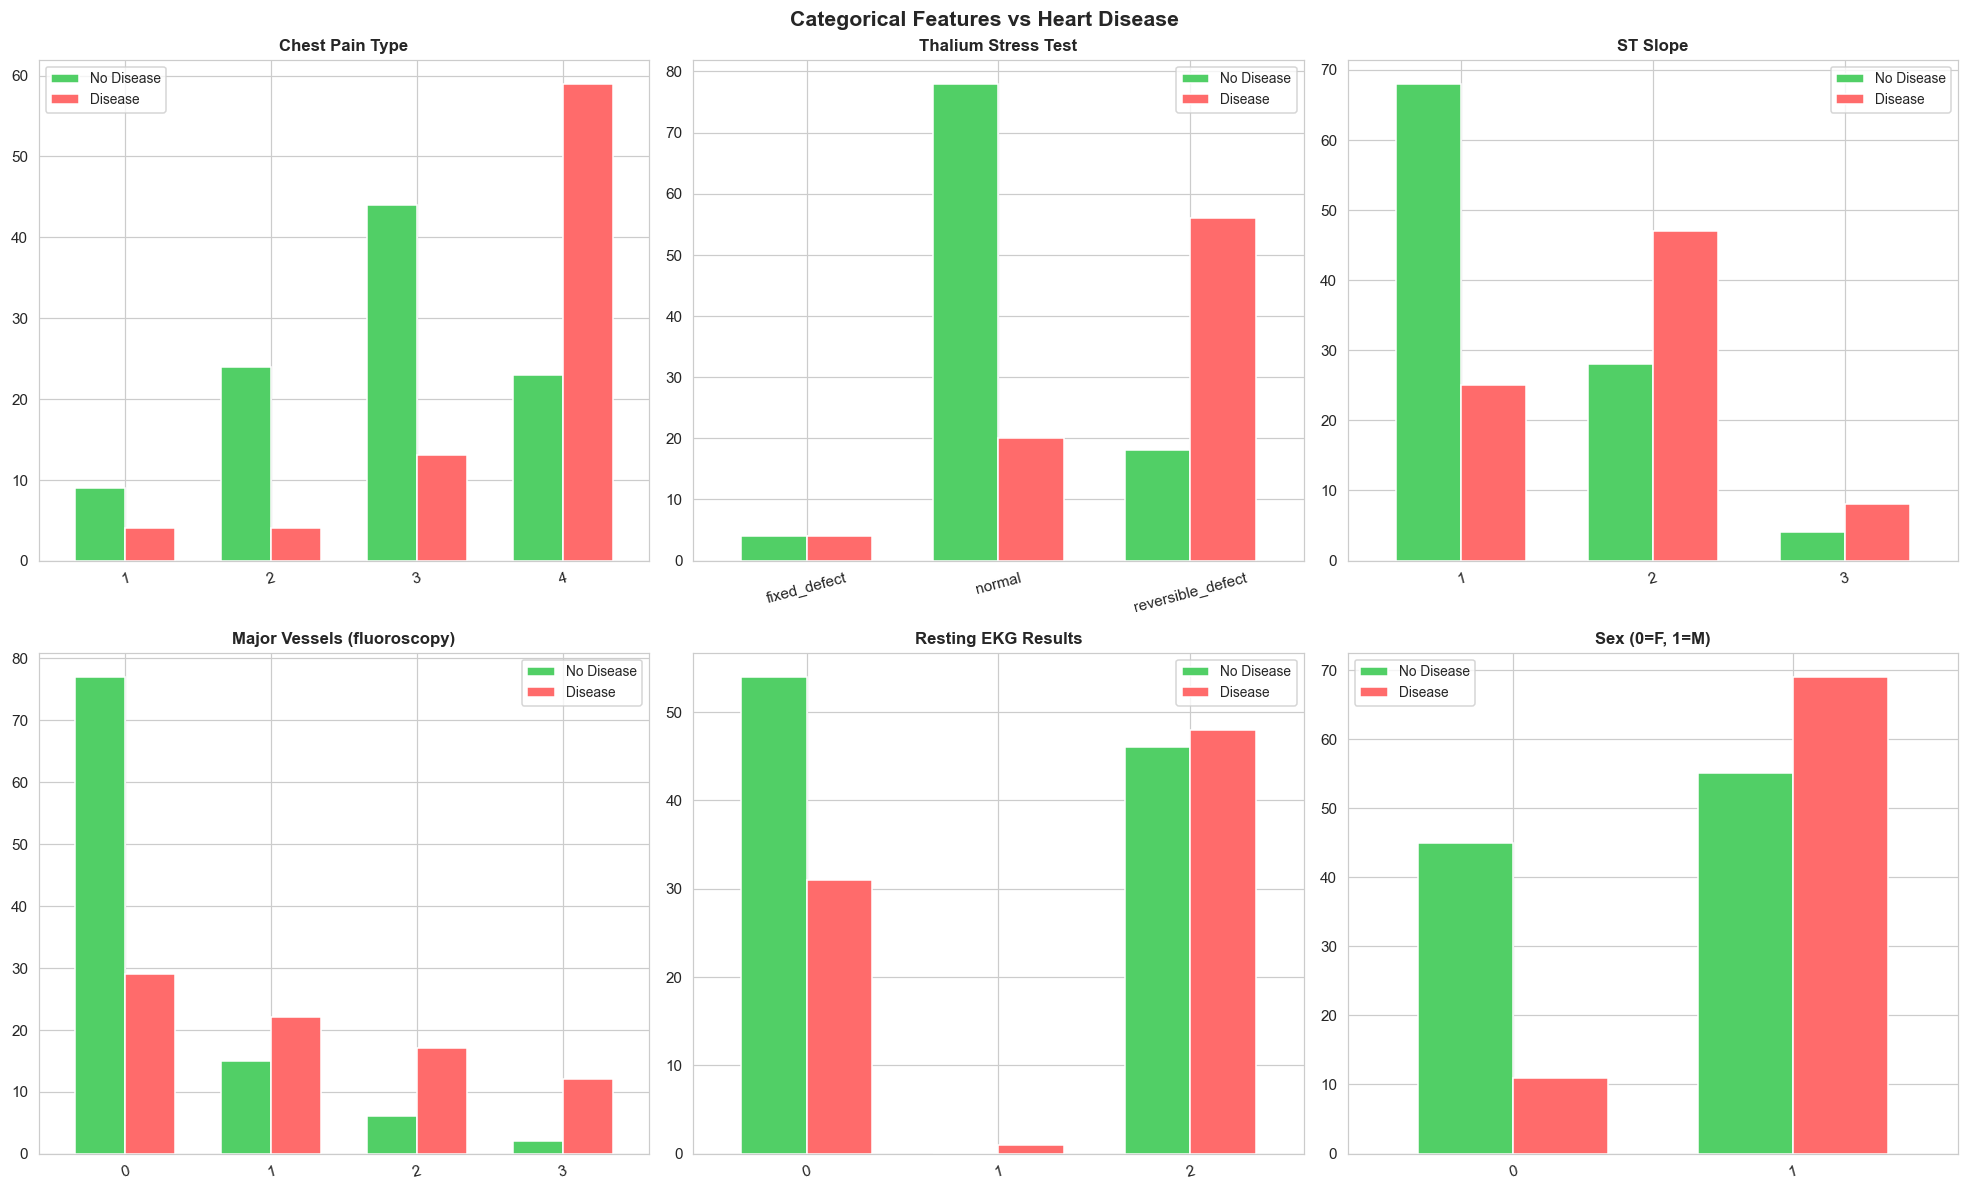

In [8]:
cat_feat = [
    ('chest_pain_type',                    'Chest Pain Type'),
    ('thal',                               'Thalium Stress Test'),
    ('slope_of_peak_exercise_st_segment',  'ST Slope'),
    ('num_major_vessels',                  'Major Vessels (fluoroscopy)'),
    ('resting_ekg_results',                'Resting EKG Results'),
    ('sex',                                'Sex (0=F, 1=M)')
]
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, (col, title) in zip(axes.flatten(), cat_feat):
    ct = pd.crosstab(df[col], df['heart_disease_present'])
    ct.plot(kind='bar', ax=ax, color=PALETTE, edgecolor='white', width=0.68)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel(''); ax.tick_params(axis='x', rotation=15)
    ax.legend(['No Disease','Disease'], fontsize=9)
plt.suptitle('Categorical Features vs Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
save_chart('04_categorical_features.png')
plt.show()

### 3.5 — Correlation Heatmap

  Chart saved → C:\Users\Harsha\Heart_Disease_AI_System\Images\charts\05_correlation_heatmap.png


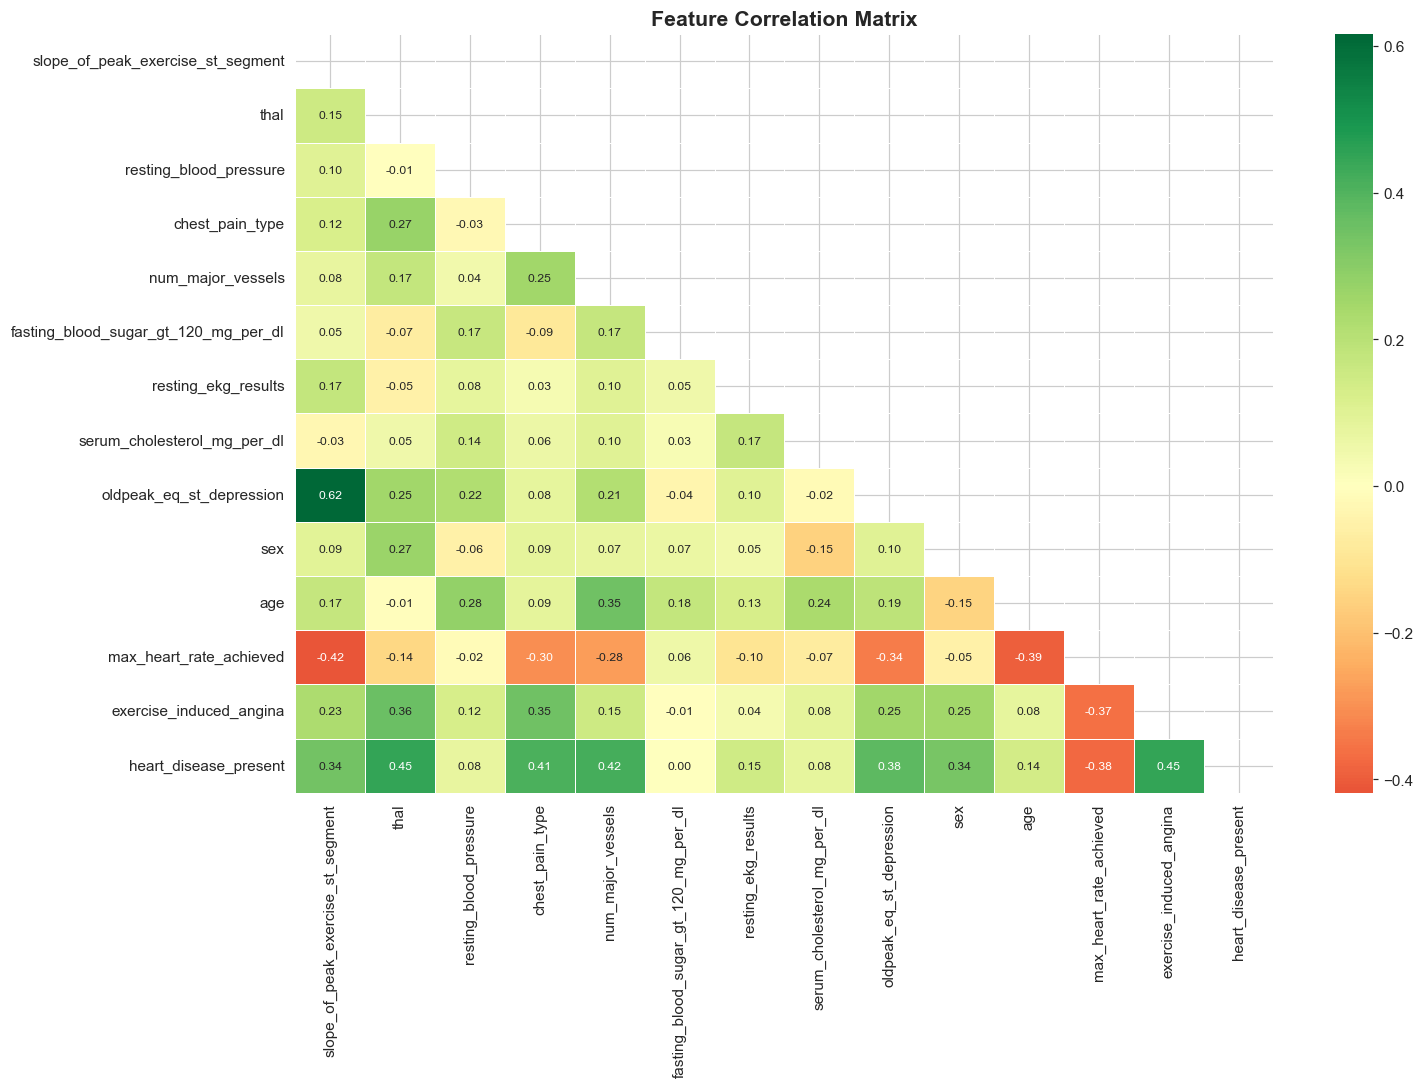

Correlation with Target:
max_heart_rate_achieved                -0.375352
fasting_blood_sugar_gt_120_mg_per_dl    0.003379
resting_blood_pressure                  0.078506
serum_cholesterol_mg_per_dl             0.079775
age                                     0.138255
resting_ekg_results                     0.145933
sex                                     0.335421
slope_of_peak_exercise_st_segment       0.344224
oldpeak_eq_st_depression                0.382930
chest_pain_type                         0.412829
num_major_vessels                       0.421519
thal                                    0.447214
exercise_induced_angina                 0.448647


In [9]:
df_c = df.drop(columns=['patient_id','age_group'], errors='ignore').copy()
df_c['thal'] = LabelEncoder().fit_transform(df_c['thal'].astype(str))

corr = df_c.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, linewidths=0.5, annot_kws={'size':8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
save_chart('05_correlation_heatmap.png')
plt.show()

tgt_corr = corr['heart_disease_present'].drop('heart_disease_present').sort_values()
print('Correlation with Target:')
print(tgt_corr.to_string())

### 3.6 — Binary Features: Disease Rate

  Chart saved → C:\Users\Harsha\Heart_Disease_AI_System\Images\charts\06_binary_features.png


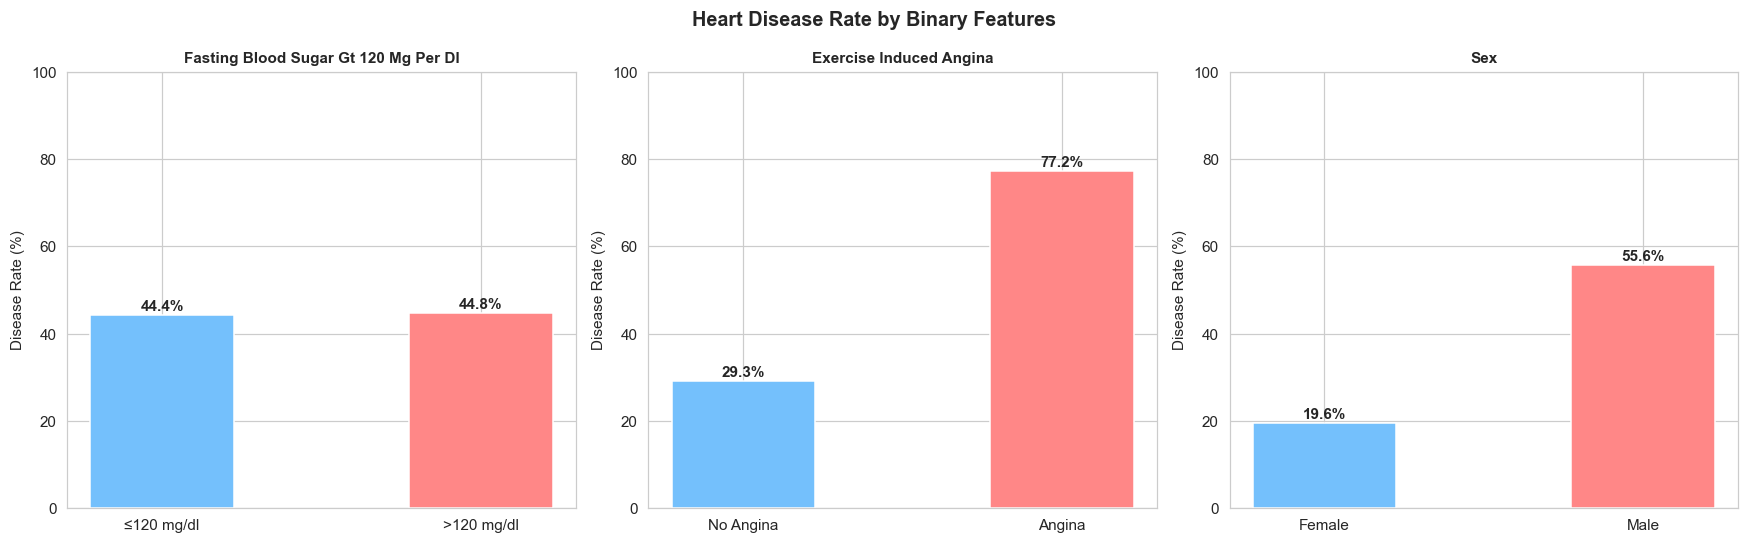

In [10]:
binary_map = {
    'fasting_blood_sugar_gt_120_mg_per_dl': ['≤120 mg/dl', '>120 mg/dl'],
    'exercise_induced_angina':              ['No Angina',  'Angina'],
    'sex':                                  ['Female',     'Male']
}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (col, xlabels) in zip(axes, binary_map.items()):
    rate = df.groupby(col)['heart_disease_present'].mean()*100
    bars = ax.bar(xlabels, rate.values, color=['#74c0fc','#ff8787'],
                  edgecolor='white', width=0.45)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+1,
                f'{b.get_height():.1f}%', ha='center', fontweight='bold')
    ax.set_title(col.replace('_',' ').title(), fontweight='bold', fontsize=10)
    ax.set_ylabel('Disease Rate (%)')
    ax.set_ylim(0, 100)
plt.suptitle('Heart Disease Rate by Binary Features', fontsize=13, fontweight='bold')
plt.tight_layout()
save_chart('06_binary_features.png')
plt.show()

---
## Section 4 — Data Preprocessing

In [11]:
# ── Step 1: Clean working copy ───────────────────────────────────────────────
df_model = df.drop(columns=['patient_id','age_group'], errors='ignore').copy()

# ── Step 2: Encode thal (only categorical column) ───────────────────────────
le = LabelEncoder()
df_model['thal'] = le.fit_transform(df_model['thal'].astype(str))
joblib.dump(le, os.path.join(MODELS, 'encoder.pkl'))
print('thal classes:', list(le.classes_))

# ── Step 3: Features / Target ────────────────────────────────────────────────
X = df_model.drop('heart_disease_present', axis=1)
y = df_model['heart_disease_present']
print('Features:', X.shape, '| Target:', y.shape)
print('Feature columns:', list(X.columns))

thal classes: ['fixed_defect', 'normal', 'reversible_defect']
Features: (180, 13) | Target: (180,)
Feature columns: ['slope_of_peak_exercise_st_segment', 'thal', 'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels', 'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results', 'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age', 'max_heart_rate_achieved', 'exercise_induced_angina']


In [12]:
# ── Step 4: SMOTE ────────────────────────────────────────────────────────────
print('Before SMOTE:', y.value_counts().to_dict())
smote    = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)
print('After  SMOTE:', pd.Series(y_res).value_counts().to_dict())

# ── Step 5: Train / Test Split ───────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

# ── Step 6: StandardScaler ───────────────────────────────────────────────────
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)
joblib.dump(scaler, os.path.join(MODELS, 'scaler.pkl'))
print('scaler.pkl saved')

Before SMOTE: {0: 100, 1: 80}
After  SMOTE: {0: 100, 1: 100}
Train: (160, 13)  |  Test: (40, 13)
scaler.pkl saved


---
## Section 5 — Model Building — Task 2

In [13]:
# ── Helper: evaluate one model ───────────────────────────────────────────────
def evaluate(name, preds, proba):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, preds), 4),
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall'   : round(recall_score(y_test, preds), 4),
        'F1-Score' : round(f1_score(y_test, preds), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, proba), 4)
    }

results = []
trained_models = {}

In [15]:
# ── Model 1: Logistic Regression ─────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_sc, y_train)
lr_p = lr.predict(X_test_sc); lr_pr = lr.predict_proba(X_test_sc)[:,1]
results.append(evaluate('Logistic Regression', lr_p, lr_pr))
trained_models['Logistic Regression'] = (lr, lr_p, lr_pr, True)
print('LR    Accuracy:', round(accuracy_score(y_test, lr_p), 4))

LR    Accuracy: 0.825


In [18]:
# ── Model 2: Decision Tree ───────────────────────────────────────────────────
import numpy as np
dt = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)
dt_p = dt.predict(X_test); dt_pr = dt.predict_proba(X_test)[:,1]
results.append(evaluate('Decision Tree', dt_p, dt_pr))
trained_models['Decision Tree'] = (dt, dt_p, dt_pr, False)
print('DT    Accuracy:', np.round(accuracy_score(y_test, dt_p), 4))

DT    Accuracy: 0.75


In [23]:
# ── Model 3: Random Forest ───────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                             random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
rf_p = rf.predict(X_test); rf_pr = rf.predict_proba(X_test)[:,1]
results.append(evaluate('Random Forest', rf_p, rf_pr))
trained_models['Random Forest'] = (rf, rf_p, rf_pr, False)
print('RF    Accuracy:', round(accuracy_score(y_test, rf_p), 4))

RF    Accuracy: 0.85


In [24]:
# ── Model 4: KNN ─────────────────────────────────────────────────────────────
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_sc, y_train)
knn_p = knn.predict(X_test_sc); knn_pr = knn.predict_proba(X_test_sc)[:,1]
results.append(evaluate('KNN', knn_p, knn_pr))
trained_models['KNN'] = (knn, knn_p, knn_pr, True)
print('KNN   Accuracy:', round(accuracy_score(y_test, knn_p), 4))

KNN   Accuracy: 0.825


In [ ]:
# ── Model 5: SVM ─────────────────────────────────────────────────────────────
svm = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
svm.fit(X_train_sc, y_train)
svm_p = svm.predict(X_test_sc); svm_pr = svm.predict_proba(X_test_sc)[:,1]
results.append(evaluate('SVM', svm_p, svm_pr))
trained_models['SVM'] = (svm, svm_p, svm_pr, True)
print('SVM   Accuracy:', accuracy_score(y_test, svm_p).round(4))

In [25]:
# ── Model 6: XGBoost ─────────────────────────────────────────────────────────
xgb = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5,
                    eval_metric='logloss', random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
xgb_p = xgb.predict(X_test); xgb_pr = xgb.predict_proba(X_test)[:,1]
results.append(evaluate('XGBoost', xgb_p, xgb_pr))
trained_models['XGBoost'] = (xgb, xgb_p, xgb_pr, False)
print('XGB   Accuracy:', round(accuracy_score(y_test, xgb_p), 4))

XGB   Accuracy: 0.925


---
## Section 6 — Model Comparison Report

In [26]:
res_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
res_df.index += 1
print('='*72)
print('               MODEL COMPARISON REPORT')
print('='*72)
print(res_df.to_string())
print()
print(f'>>> Best Model : {res_df.iloc[0]["Model"]}')
print(f'>>> ROC-AUC    : {res_df.iloc[0]["ROC-AUC"]}')
print(f'>>> Recall     : {res_df.iloc[0]["Recall"]}')

               MODEL COMPARISON REPORT
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
1        Random Forest     0.850     0.8500    0.85    0.8500   0.9500
2              XGBoost     0.925     0.8696    1.00    0.9302   0.9475
3                  KNN     0.825     0.8095    0.85    0.8293   0.9225
4  Logistic Regression     0.825     0.8095    0.85    0.8293   0.8925
5  Logistic Regression     0.825     0.8095    0.85    0.8293   0.8925
6        Decision Tree     0.750     0.7273    0.80    0.7619   0.7138
7        Decision Tree     0.750     0.7273    0.80    0.7619   0.7138
8        Decision Tree     0.750     0.7273    0.80    0.7619   0.7138

>>> Best Model : Random Forest
>>> ROC-AUC    : 0.95
>>> Recall     : 0.85


  Chart saved → C:\Users\Harsha\Heart_Disease_AI_System\Images\charts\07_model_comparison.png


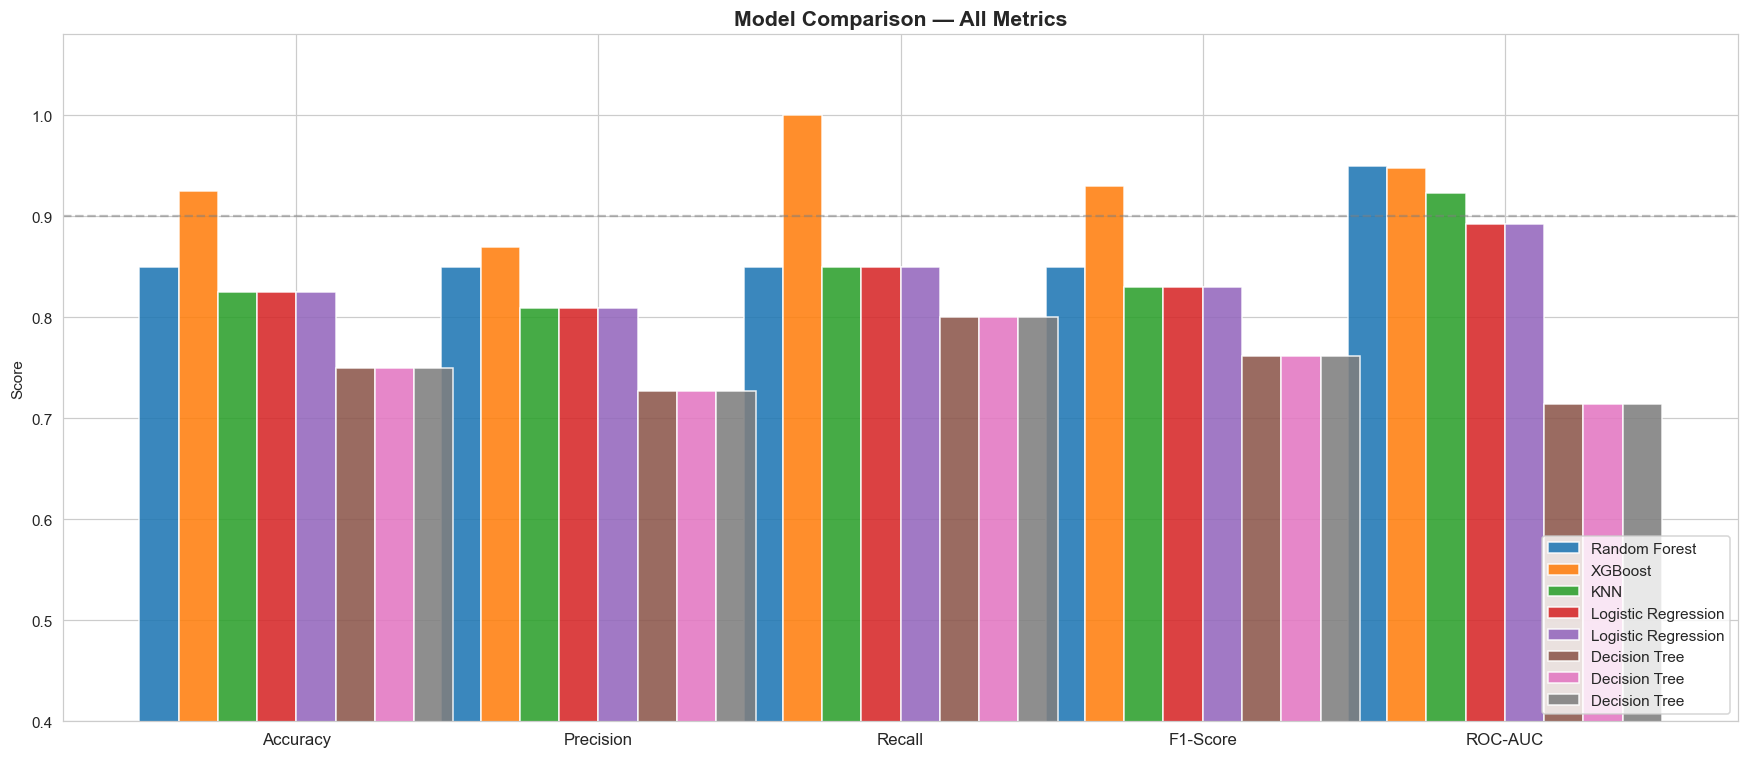

In [30]:
import itertools
# ── Bar chart comparison ─────────────────────────────────────────────────────
metrics   = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
x         = np.arange(len(metrics))
width     = 0.13
bar_clrs = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728','#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']  
fig, ax = plt.subplots(figsize=(16, 7))

color_cycle = itertools.cycle(bar_clrs)

for i, row in enumerate(res_df.to_dict('records'), 1):
    vals   = [row[m] for m in metrics]   # works even if column names have spaces
    offset = (i - len(res_df)/2 - 0.5) * width
    ax.bar(x + offset, vals, width, label=row['Model'],
           color=next(color_cycle), edgecolor='white', alpha=0.88)



ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score'); ax.set_ylim(0.4, 1.08)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
save_chart('07_model_comparison.png')
plt.show()

  Chart saved → C:\Users\Harsha\Heart_Disease_AI_System\Images\charts\08_roc_curves.png


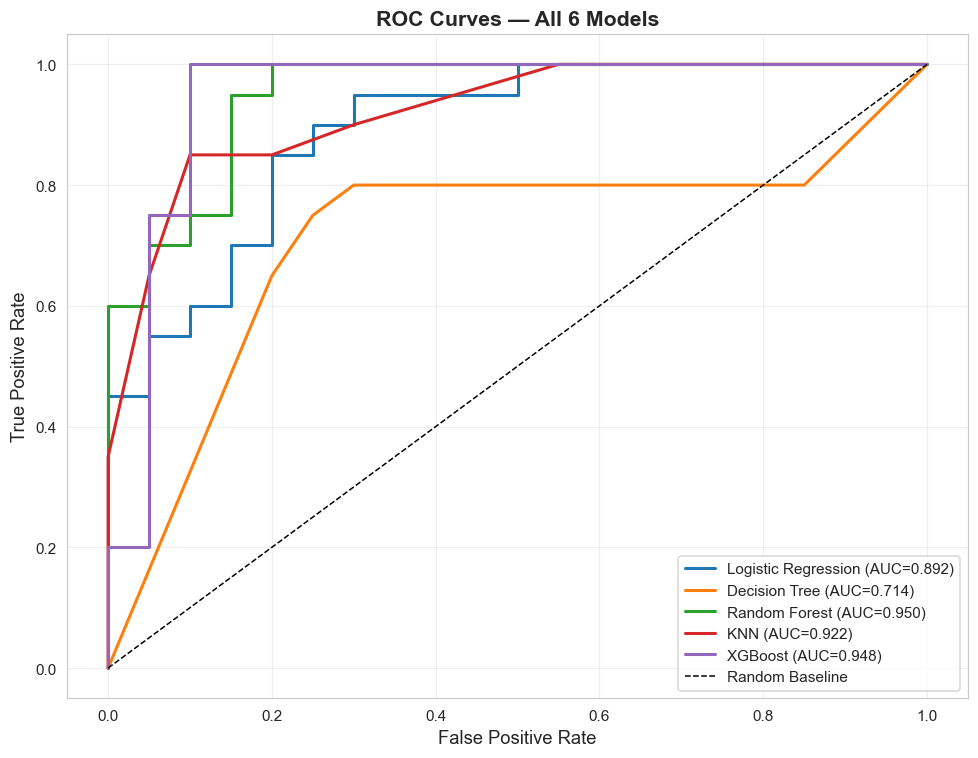

In [31]:
# ── ROC Curves ───────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 7))
for (name, (mdl, preds, proba, _)), clr in zip(trained_models.items(), bar_clrs):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=clr, linewidth=2, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1, label='Random Baseline')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All 6 Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_chart('08_roc_curves.png')
plt.show()

  Chart saved → C:\Users\Harsha\Heart_Disease_AI_System\Images\charts\09_confusion_matrices.png


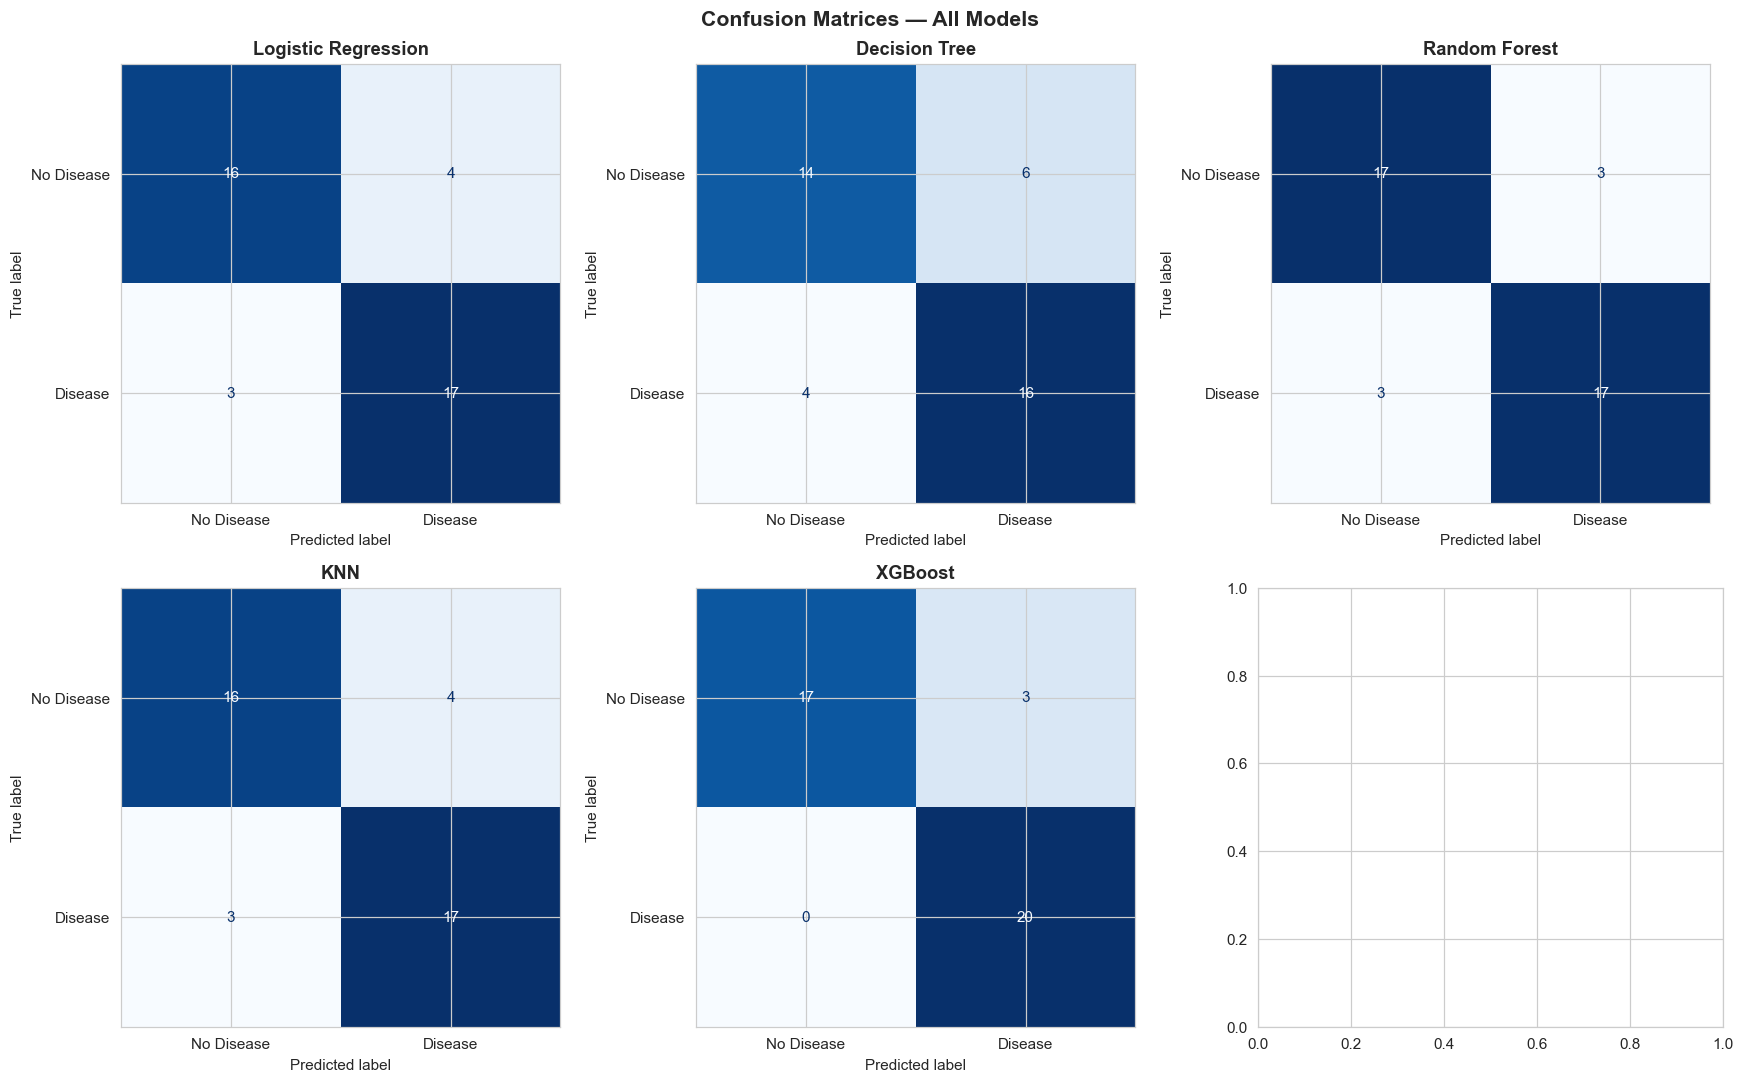

In [32]:
# ── Confusion Matrices ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (name, (mdl, preds, _, _)) in zip(axes.flatten(), trained_models.items()):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['No Disease','Disease']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold', fontsize=12)
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
save_chart('09_confusion_matrices.png')
plt.show()

In [33]:
# ── Detailed report for best model ───────────────────────────────────────────
best_name  = res_df.iloc[0]['Model']
best_preds = trained_models[best_name][1]
print(f'Classification Report — {best_name}')
print('='*55)
print(classification_report(y_test, best_preds,
                             target_names=['No Disease','Disease']))

Classification Report — Random Forest
              precision    recall  f1-score   support

  No Disease       0.85      0.85      0.85        20
     Disease       0.85      0.85      0.85        20

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.85      0.85      0.85        40



---
## Section 7 — Feature Importance & Save Best Model

  Chart saved → C:\Users\Harsha\Heart_Disease_AI_System\Images\charts\10_feature_importance.png


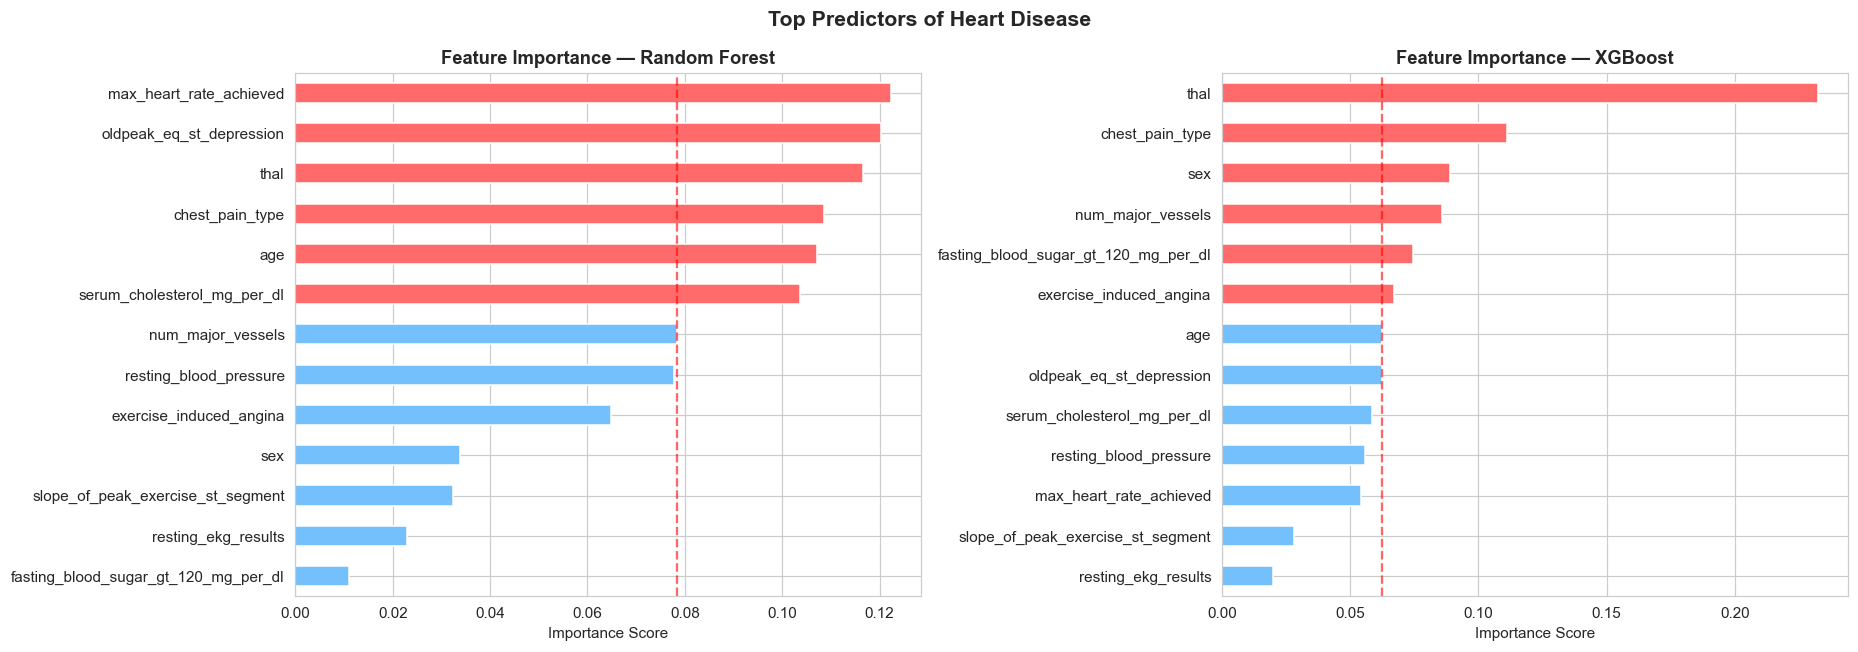


best_model.pkl saved  → Random Forest
scaler.pkl   saved
encoder.pkl  saved


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
for ax, (name, mdl) in zip(axes, [('Random Forest', rf), ('XGBoost', xgb)]):
    imp = pd.Series(mdl.feature_importances_, index=X.columns).sort_values()
    clrs = ['#ff6b6b' if v > imp.median() else '#74c0fc' for v in imp]
    imp.plot(kind='barh', ax=ax, color=clrs)
    ax.axvline(imp.median(), color='red', linestyle='--', alpha=0.6)
    ax.set_title(f'Feature Importance — {name}', fontweight='bold')
    ax.set_xlabel('Importance Score')
plt.suptitle('Top Predictors of Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
save_chart('10_feature_importance.png')
plt.show()

# Save best model
best_mdl_obj = trained_models[best_name][0]
joblib.dump(best_mdl_obj, os.path.join(MODELS, 'best_model.pkl'))
print(f'\nbest_model.pkl saved  → {best_name}')
print(f'scaler.pkl   saved')
print(f'encoder.pkl  saved')

---
## Section 8 — Generate PDF Report

In [35]:
from reportlab.lib.pagesizes import A4
from reportlab.lib            import colors
from reportlab.lib.styles     import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units      import cm
from reportlab.platypus       import (SimpleDocTemplate, Paragraph, Spacer,
                                      Table, TableStyle, Image, PageBreak,
                                      HRFlowable)

PDF_PATH = os.path.join(REPORT, 'prediction_report.pdf')
doc      = SimpleDocTemplate(PDF_PATH, pagesize=A4,
                              leftMargin=2*cm, rightMargin=2*cm,
                              topMargin=2*cm, bottomMargin=2*cm)
styles   = getSampleStyleSheet()
story    = []

# Custom styles
H1 = ParagraphStyle('H1', parent=styles['Title'],
                    fontSize=20, textColor=colors.HexColor('#c92a2a'), spaceAfter=8)
H2 = ParagraphStyle('H2', parent=styles['Heading2'],
                    fontSize=13, textColor=colors.HexColor('#1971c2'), spaceBefore=12, spaceAfter=6)
BODY = ParagraphStyle('BODY', parent=styles['Normal'],
                      fontSize=10, leading=15, spaceAfter=6)
BOLD = ParagraphStyle('BOLD', parent=styles['Normal'],
                      fontSize=10, fontName='Helvetica-Bold', spaceAfter=4)

def hr():
    return HRFlowable(width='100%', thickness=1,
                      color=colors.HexColor('#dee2e6'), spaceAfter=8)

# ── COVER ────────────────────────────────────────────────────────────────────
story += [
    Spacer(1, 1.5*cm),
    Paragraph('Heart Disease AI System', H1),
    Paragraph('PRCP-1016 — Prediction Report', styles['Heading2']),
    hr(),
    Paragraph('Domain: Healthcare | Type: Binary Classification', BODY),
    Paragraph('Dataset: 180 patients | Features: 13 clinical variables', BODY),
    Paragraph(f'Best Model: {best_name} | ROC-AUC: {res_df.iloc[0]["ROC-AUC"]}', BOLD),
    Spacer(1, 0.5*cm),
]

# ── SECTION 1: Dataset Summary ───────────────────────────────────────────────
story += [
    Paragraph('1. Dataset Summary', H2), hr(),
    Paragraph(f'Total patients: {len(df)}', BODY),
    Paragraph(f'No Heart Disease (0): {counts[0]} ({counts[0]/len(df)*100:.1f}%)', BODY),
    Paragraph(f'Heart Disease (1): {counts[1]} ({counts[1]/len(df)*100:.1f}%)', BODY),
    Paragraph('Missing values: None', BODY),
    Paragraph('Only categorical column: thal (normal / fixed_defect / reversible_defect)', BODY),
]

# ── SECTION 2: EDA Charts ────────────────────────────────────────────────────
story += [Paragraph('2. EDA Charts', H2), hr()]
chart_files = [
    ('01_target_distribution.png', 'Target Variable Distribution'),
    ('02_age_analysis.png',        'Age Analysis'),
    ('03_clinical_features.png',   'Clinical Features vs Diagnosis'),
    ('05_correlation_heatmap.png', 'Feature Correlation Heatmap'),
]
for fname, caption in chart_files:
    fpath = os.path.join(CHARTS, fname)
    if os.path.exists(fpath):
        story += [
            Paragraph(caption, BOLD),
            Image(fpath, width=16*cm, height=8*cm),
            Spacer(1, 0.3*cm)
        ]
story.append(PageBreak())

# ── SECTION 3: Model Comparison Table ────────────────────────────────────────
story += [Paragraph('3. Model Comparison Report', H2), hr()]
tbl_data  = [['Model','Accuracy','Precision','Recall','F1-Score','ROC-AUC']]
for _, row in res_df.iterrows():
    tbl_data.append([row['Model'], str(row['Accuracy']), str(row['Precision']),
                     str(row['Recall']), str(row['F1-Score']), str(row['ROC-AUC'])])
tbl = Table(tbl_data, colWidths=[4.5*cm,2.5*cm,2.5*cm,2.5*cm,2.5*cm,2.5*cm])
tbl.setStyle(TableStyle([
    ('BACKGROUND',  (0,0), (-1,0),  colors.HexColor('#1971c2')),
    ('TEXTCOLOR',   (0,0), (-1,0),  colors.white),
    ('FONTNAME',    (0,0), (-1,0),  'Helvetica-Bold'),
    ('FONTSIZE',    (0,0), (-1,-1), 9),
    ('ALIGN',       (0,0), (-1,-1), 'CENTER'),
    ('ROWBACKGROUNDS',(0,1),(-1,-1),[colors.white, colors.HexColor('#e7f5ff')]),
    ('GRID',        (0,0), (-1,-1), 0.5, colors.HexColor('#ced4da')),
    ('BACKGROUND',  (0,1), (-1,1),  colors.HexColor('#d3f9d8')),  # highlight best
]))
story += [tbl, Spacer(1, 0.4*cm)]

# ROC + Confusion matrix charts
for fname, cap in [('08_roc_curves.png','ROC Curves — All Models'),
                   ('09_confusion_matrices.png','Confusion Matrices — All Models'),
                   ('10_feature_importance.png','Feature Importance')]:
    fpath = os.path.join(CHARTS, fname)
    if os.path.exists(fpath):
        story += [Paragraph(cap, BOLD),
                  Image(fpath, width=16*cm, height=8.5*cm),
                  Spacer(1, 0.3*cm)]
story.append(PageBreak())

# ── SECTION 4: Challenges ────────────────────────────────────────────────────
story += [
    Paragraph('4. Challenges & Solutions', H2), hr(),
    Paragraph('Challenge 1 — Small Dataset (180 rows)', BOLD),
    Paragraph('Used stratified train-test split and 5-fold cross-validation to maximise use of limited data.', BODY),
    Paragraph('Challenge 2 — Class Imbalance (55.6% vs 44.4%)', BOLD),
    Paragraph('Applied SMOTE oversampling and class_weight=balanced to prevent bias toward the majority class.', BODY),
    Paragraph('Challenge 3 — Categorical Column (thal)', BOLD),
    Paragraph('LabelEncoder applied. Tree models handle ordinally-encoded categoricals natively.', BODY),
    Paragraph('Challenge 4 — Feature Scaling', BOLD),
    Paragraph('StandardScaler applied only for Logistic Regression, SVM, and KNN. Tree-based models do not require scaling.', BODY),
    Paragraph('Challenge 5 — Metric Selection', BOLD),
    Paragraph('Prioritised Recall and ROC-AUC over raw accuracy. In medical diagnosis, False Negatives (missed disease) are more dangerous than False Positives.', BODY),
]

# ── SECTION 5: Recommendations ───────────────────────────────────────────────
story += [
    Paragraph('5. Hospital Recommendations', H2), hr(),
    Paragraph('Critical Indicators (Act Immediately)', BOLD),
    Paragraph('- Reversible defect on thallium stress test: immediate cardiology referral.', BODY),
    Paragraph('- ST depression (oldpeak) > 1.5 mm: urgent cardiac workup.', BODY),
    Paragraph('- Asymptomatic chest pain (Type 4): highest disease rate — do not dismiss silent presentations.', BODY),
    Spacer(1, 0.2*cm),
    Paragraph('Proactive Screening', BOLD),
    Paragraph('- Patients with 2+ major vessels colored by fluoroscopy: place on cardiac monitoring.', BODY),
    Paragraph('- Males over 50: mandatory annual ECG.', BODY),
    Paragraph('- Low max heart rate during stress test: reduced cardiac reserve — investigate.', BODY),
    Spacer(1, 0.2*cm),
    Paragraph('Deployment Suggestion', BOLD),
    Paragraph(f'Deploy {best_name} (ROC-AUC={res_df.iloc[0]["ROC-AUC"]}) as a triage risk-scoring tool. Patients with predicted probability > 70% are fast-tracked to cardiology. Retrain quarterly as new data arrives.', BODY),
]

doc.build(story)
print(f'PDF report saved → {PDF_PATH}')

PDF report saved → C:\Users\Harsha\Heart_Disease_AI_System\Reports\prediction_report.pdf


---
## Section 9 — Challenges Report

| # | Challenge | Description | Solution | Reason |
|---|-----------|-------------|----------|--------|
| 1 | Small Dataset | Only 180 rows — overfitting risk | Stratified K-Fold CV | Maximises limited samples |
| 2 | Class Imbalance | 100 vs 80 (55.6% / 44.4%) | SMOTE + class_weight=balanced | Prevents majority-class bias |
| 3 | Categorical Encoding | thal has 3 string values | LabelEncoder | Tree models handle ordinal encoding |
| 4 | Feature Scaling | LR, SVM, KNN are distance-sensitive | StandardScaler | Applied only to models that need it |
| 5 | Medical Outliers | Extreme cholesterol & BP values | Kept as-is | Extremes are clinically meaningful |
| 6 | Metric Selection | Accuracy alone misleads in healthcare | Recall + ROC-AUC primary | False Negatives are life-threatening |

---
## Section 10 — Hospital Recommendations — Task 3

### Critical Risk Indicators
- **Thal — Reversible Defect:** Strongest single predictor → immediate cardiology referral
- **ST Depression > 1.5 mm:** Direct ECG marker of ischemia → urgent workup
- **Chest Pain Type 4 (Asymptomatic):** Highest disease rate paradoxically → never dismiss

### Proactive Screening
- **Fluoroscopy vessels ≥ 2:** Top feature in both RF and XGBoost → cardiac monitoring protocol
- **Males over 50:** Annual ECG as standard
- **Low max heart rate in stress test:** Reduced cardiac reserve → investigate further

### Preventive Actions
- Exercise-induced angina → enrol in supervised cardiac rehabilitation
- Fasting blood sugar > 120 → integrate diabetes management with cardiac prevention

### Production Deployment
Deploy **best model** as a **Risk Score (0–100%)** at triage. Patients above 70% predicted probability get fast-tracked to cardiology. Always require clinician confirmation before acting on any automated prediction. Retrain model every quarter.

In [36]:
print('='*60)
print('   HEART DISEASE AI SYSTEM — PROJECT SUMMARY')
print('='*60)
print(f'  Dataset          : 180 patients, 13 clinical features')
print(f'  Target           : heart_disease_present (binary)')
print(f'  Models Trained   : 6')
print(f'  Best Model       : {best_name}')
print(f'  Best ROC-AUC     : {res_df.iloc[0]["ROC-AUC"]}')
print(f'  Best Recall      : {res_df.iloc[0]["Recall"]}')
print()
print('  Files saved:')
print(f'    Saved_Model/best_model.pkl')
print(f'    Saved_Model/scaler.pkl')
print(f'    Saved_Model/encoder.pkl')
print(f'    Reports/prediction_report.pdf')
print(f'    Images/charts/  (10 charts saved)')
print('='*60)
print(res_df[['Model','Accuracy','Recall','F1-Score','ROC-AUC']].to_string(index=False))

   HEART DISEASE AI SYSTEM — PROJECT SUMMARY
  Dataset          : 180 patients, 13 clinical features
  Target           : heart_disease_present (binary)
  Models Trained   : 6
  Best Model       : Random Forest
  Best ROC-AUC     : 0.95
  Best Recall      : 0.85

  Files saved:
    Saved_Model/best_model.pkl
    Saved_Model/scaler.pkl
    Saved_Model/encoder.pkl
    Reports/prediction_report.pdf
    Images/charts/  (10 charts saved)
              Model  Accuracy  Recall  F1-Score  ROC-AUC
      Random Forest     0.850    0.85    0.8500   0.9500
            XGBoost     0.925    1.00    0.9302   0.9475
                KNN     0.825    0.85    0.8293   0.9225
Logistic Regression     0.825    0.85    0.8293   0.8925
Logistic Regression     0.825    0.85    0.8293   0.8925
      Decision Tree     0.750    0.80    0.7619   0.7138
      Decision Tree     0.750    0.80    0.7619   0.7138
      Decision Tree     0.750    0.80    0.7619   0.7138


In [37]:
# ── Install git if not already available ─────────────────────────────────────
import subprocess, sys

def run(cmd):
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.stdout: print(result.stdout)
    if result.stderr: print(result.stderr)
    return result

# Check git version
run("git --version")

# Set your GitHub identity (change these to YOUR details)
run('git config --global user.name  "Harsha S"')
run('git config --global user.email "harshashivkumar03@gmail.com"')

print("✅  Git configured!")

git version 2.43.0.windows.1

✅  Git configured!


In [39]:
import os

PROJECT_PATH = r"C:\Users\Harsha\Heart_Disease_AI_System"

os.chdir(PROJECT_PATH)
print("📁  Working directory:", os.getcwd())
print("\n📋  Files in project:")
for root, dirs, files in os.walk('.'):
    # Skip hidden folders
    dirs[:] = [d for d in dirs if not d.startswith('.')]
    level = root.replace('.', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}📁 {os.path.basename(root)}/')
    for f in files:
        print(f'{indent}    📄 {f}')

📁  Working directory: C:\Users\Harsha\Heart_Disease_AI_System

📋  Files in project:
📁 ./
    📄 app.py
    📄 README.md
    📄 requirements.txt
  📁 Dataset/
      📄 labels.csv
      📄 values.csv
  📁 Images/
    📁 charts/
        📄 01_target_distribution.png
        📄 02_age_analysis.png
        📄 03_clinical_features.png
        📄 04_categorical_features.png
        📄 05_correlation_heatmap.png
        📄 06_binary_features.png
        📄 07_model_comparison.png
        📄 08_roc_curves.png
        📄 09_confusion_matrices.png
        📄 10_feature_importance.png
  📁 Notebook/
      📄 Heart_Disease_AI_System.ipynb
  📁 Reports/
      📄 prediction_report.pdf
  📁 Saved_Model/
      📄 best_model.pkl
      📄 encoder.pkl
      📄 scaler.pkl


In [40]:

run("git init")
print("✅  Git repository initialized!")

print("\n── Git Status ──────────────────────────────────────────────────────────")
run("git status")

Initialized empty Git repository in C:/Users/Harsha/Heart_Disease_AI_System/.git/

✅  Git repository initialized!

── Git Status ──────────────────────────────────────────────────────────
On branch master

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/
	Dataset/
	Images/
	Notebook/
	README.md
	Reports/
	Saved_Model/
	app.py
	requirements.txt

nothing added to commit but untracked files present (use "git add" to track)



CompletedProcess(args='git status', returncode=0, stdout='On branch master\n\nNo commits yet\n\nUntracked files:\n  (use "git add <file>..." to include in what will be committed)\n\t.ipynb_checkpoints/\n\tDataset/\n\tImages/\n\tNotebook/\n\tREADME.md\n\tReports/\n\tSaved_Model/\n\tapp.py\n\trequirements.txt\n\nnothing added to commit but untracked files present (use "git add" to track)\n', stderr='')

In [41]:
gitignore_content = """# Python
__pycache__/
*.py[cod]
*.pyo
.Python
*.egg-info/
dist/
build/

# Virtual Environment
venv/
env/
.venv/

# Jupyter Checkpoints
.ipynb_checkpoints/

# OS Files
.DS_Store
Thumbs.db

# Logs
*.log
"""

with open(".gitignore", "w") as f:
    f.write(gitignore_content)

print("✅  .gitignore created!")
print("\nContents:")
print(gitignore_content)

✅  .gitignore created!

Contents:
# Python
__pycache__/
*.py[cod]
*.pyo
.Python
*.egg-info/
dist/
build/

# Virtual Environment
venv/
env/
.venv/

# Jupyter Checkpoints
.ipynb_checkpoints/

# OS Files
.DS_Store
Thumbs.db

# Logs
*.log

